# Bottleneck Deconv Training - All Latent Dimensions
Training ComplexBottleneckDeconvDecoder with BottleneckEncoder across multiple latent dimensions

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os
import time
from tqdm.auto import tqdm

# Runtime reload
import importlib
import models.autoencoder.bottleneck_models
importlib.reload(models.autoencoder.bottleneck_models)

from data.data_ingestion import collect_files, generate_dataframe
from data.dataloader import create_dataloaders
from models.autoencoder.bottleneck_models import (
    BottleneckEncoder,
    ComplexBottleneckDeconvDecoder,
    BottleneckAE,
)
from models.autoencoder.training import train_autoencoder
from models.autoencoder.config import TrainingConfig

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

def count_trainable(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

Device: cuda


## Data Setup

In [2]:
root_dir = Path(".")
images_dir = root_dir / "data" / "Images"
mask_path = root_dir / "data" / "masks" / "rmask_ICV.nii"

# Configuration
data_dir = "data/Images"
mask_path = "data/masks/rmask_ICV.nii"
batch_size = 4
output_dir = "output/Experiments/BottleneckDeconvTraining"

# Create output directory
os.makedirs(output_dir, exist_ok=True)

In [3]:
# Prepare data
print("Collecting files...")
included_files, excluded_files = collect_files(data_dir)
print(f"Found {len(included_files)} valid files, excluded {len(excluded_files)} files")

# Generate dataframe
print("Generating dataframe...")
df = generate_dataframe(included_files)
display(df.head())

# Create dataloaders
print("Creating dataloaders...")
train_loader, val_loader = create_dataloaders(
    df, batch_size=batch_size, train_split=0.8, 
    on_demand=True, mask_path=mask_path,
    num_workers=2
)

print(f"Data preparation complete. Train: {len(train_loader.dataset)}, Val: {len(val_loader.dataset)}")

Found 2976 valid files, excluded 893 files
Generating dataframe...


,file_path,label
0,data/Images/PPMI_Images_Cont/100004/Reconstruc...,Control
1,data/Images/PPMI_Images_Cont/100890/Reconstruc...,Control
2,data/Images/PPMI_Images_Cont/100956/Reconstruc...,Control
3,data/Images/PPMI_Images_Cont/101039/Reconstruc...,Control
4,data/Images/PPMI_Images_Cont/101195/Reconstruc...,Control


Creating dataloaders...

Training set distribution:
label
PD         2035
Control     235
SWEDD       110
Name: count, dtype: int64

Validation set distribution:
label
PD         510
Control     59
SWEDD       27
Name: count, dtype: int64
Using on-demand data loading strategy (lighter on memory but slower)
✅ Brain mask loaded successfully
✅ All 2380 file paths are valid
✅ Brain mask loaded successfully
✅ All 596 file paths are valid
Data preparation complete. Train: 2380, Val: 596


## Model Setup

In [4]:
target_shape = (64, 128, 128)

def build_model(latent_dim=128):
    """Build ComplexBottleneckDeconvDecoder model"""
    model = BottleneckAE(
        BottleneckEncoder(initial_filters=4, latent_dim=latent_dim, bottleneck_shape=(1,1,1)),
        ComplexBottleneckDeconvDecoder(latent_dim=latent_dim, target_shape=target_shape),
    )
    return model.to(device)

def create_training_config(model_name, epochs=10, latent_dim=512):
    """Create a training configuration for a model"""
    config = TrainingConfig()
    config.latent_dim = latent_dim
    config.epochs = epochs
    config.model_name = model_name
    config.checkpoint_dir = os.path.join(output_dir, model_name)
    config.early_stopping_patience = 10
    config.save_interval = 5
    config.learning_rate = 1e-4
    config.use_mixed_precision = True
    return config

## Training All Latent Dimensions

In [ ]:
# Latent dimensions to test
deconv_latent_dims = [512, 256, 128, 64, 32]
deconv_histories = {}
deconv_results = []

num_epochs = 150

for idx, latent_dim in enumerate(deconv_latent_dims[0:1]):
    model_name = f"deconv_lat{latent_dim}"
    print(f"\n[{idx+1}/{len(deconv_latent_dims)}] ================== Training {model_name} ==================")
    
    cfg = create_training_config(model_name, num_epochs, latent_dim)
    model = build_model(latent_dim=latent_dim)
    
    # Count parameters
    num_params = count_trainable(model)
    print(f"Parameters: {num_params / 1e6:.2f}M")
    
    # Time the training
    start_time = time.time()
    
    train_losses, val_losses, trained_model = train_autoencoder(
        model,
        train_loader,
        val_loader,
        config=cfg,
        disable_epoch_bars=True,
        criterion=None,  # default MSE
    )
    
    elapsed_time = time.time() - start_time
    time_per_epoch = elapsed_time / num_epochs
    
    deconv_histories[model_name] = {"train": train_losses, "val": val_losses}
    deconv_results.append({
        "Model": model_name,
        "Latent Dim": latent_dim,
        "Parameters": num_params,
        "Final Val Loss": val_losses[-1],
        "Best Val Loss": min(val_losses),
        "Final Train Loss": train_losses[-1],
        "Total Time (s)": elapsed_time,
        "Time per Epoch (s)": time_per_epoch,
    })
    
    print(f"✓ Completed in {elapsed_time:.1f}s | Time/Epoch: {time_per_epoch:.2f}s | Final Val Loss: {val_losses[-1]:.6f}")


[1/5] ================== Training deconv_lat512 ==================

TRAINING CONFIGURATION
Model: autoencoder with latent dim 256
Batch size: 4 × 4 steps = 16 effective
Learning rate: 0.0001
Mixed precision: Enabled
Epochs: 100 with patience 10
Dataloader workers: 2
Checkpoints saved to: checkpoints

Parameters: 25.90M
DEBUG: CheckpointHandler - Attempting to load checkpoint from output/Experiments/BottleneckDeconvTraining/deconv_lat512/deconv_lat512_checkpoint.pth
No checkpoint found at output/Experiments/BottleneckDeconvTraining/deconv_lat512/deconv_lat512_checkpoint.pth
DEBUG: Starting training loop


Progress [E1/150|Train]:   0%|                                                                | 0/89250 [00:00<?, ?it/s]

DEBUG: Starting epoch 1/150


Progress [E1/150|Val]:   1%|▎                                                     | 595/89250 [00:30<1:13:38, 20.06it/s]

DEBUG: CheckpointHandler - Saving checkpoint for epoch 0
DEBUG: CheckpointHandler - Saved checkpoint to output/Experiments/BottleneckDeconvTraining/deconv_lat512/deconv_lat512_checkpoint.pth


...

Progress [E6/150|Val]:   4%|██                                                   | 3570/89250 [03:34<1:08:09, 20.95it/s]

DEBUG: CheckpointHandler - Saving checkpoint for epoch 5
DEBUG: CheckpointHandler - Saved checkpoint to output/Experiments/BottleneckDeconvTraining/deconv_lat512/deconv_lat512_checkpoint.pth


Progress [E7/150|Train]:   4%|██                                                 | 3570/89250 [03:40<1:08:09, 20.95it/s]

Saved best model to output/Experiments/BottleneckDeconvTraining/deconv_lat512/deconv_lat512_best.pth
DEBUG: CheckpointHandler - Saved metadata to output/Experiments/BottleneckDeconvTraining/deconv_lat512/deconv_lat512_metadata.json
Epoch 6/150 | Train: 0.007174 | Val: 0.006575 | LR: 0.00010000 | ETA: 88.35m

GPU Memory Usage:
Allocated: 640.45 MB
Cached: 700.00 MB
CPU Memory Usage: 2207.44 MB
Validation loss improved by 0.001095
DEBUG: Starting epoch 7/150


Progress [E7/150|Train]:   4%|██                                                 | 3579/89250 [03:41<7:36:20,  3.13it/s]

In [16]:
deconv_results

[{'Model': 'deconv_lat64',
  'Latent Dim': 64,
  'Parameters': 3883213,
  'Final Val Loss': 0.004033136487807203,
  'Best Val Loss': 0.00402497583937725,
  'Final Train Loss': 0.0037711597196444743,
  'Total Time (s)': 4907.219494819641,
  'Time per Epoch (s)': 32.71479663213094}]

## Results Summary

In [21]:
# Create results dataframe
#results_df = pd.DataFrame(deconv_results)
results_df = pd.read_csv('output/Experiments/BottleneckDeconvTraining/training_results.csv')
display(results_df)

# Save results
results_df.to_csv(os.path.join(output_dir, "training_results.csv"), index=False)
print(f"\nResults saved to {os.path.join(output_dir, 'training_results.csv')}")

,Model,Latent Dim,Parameters,Final Val Loss,Best Val Loss,Final Train Loss,Total Time (s),Time per Epoch (s)
0,deconv_lat512,512,25903757,0.003169,0.003163,0.002472,5404.805475,27.639459
1,deconv_lat256,256,13320589,0.003692,0.003666,0.003094,5259.425024,35.062833
2,deconv_lat128,128,7029005,0.003686,0.003683,0.003323,5455.424562,36.369497
3,deconv_lat64,64,3883213,0.004033,0.004025,0.003771,4979.979154,33.199861
4,deconv_lat32,32,2310317,0.004000,0.003982,0.003744,5852.523212,39.016821



Results saved to output/Experiments/BottleneckDeconvTraining/training_results.csv


## Visualization

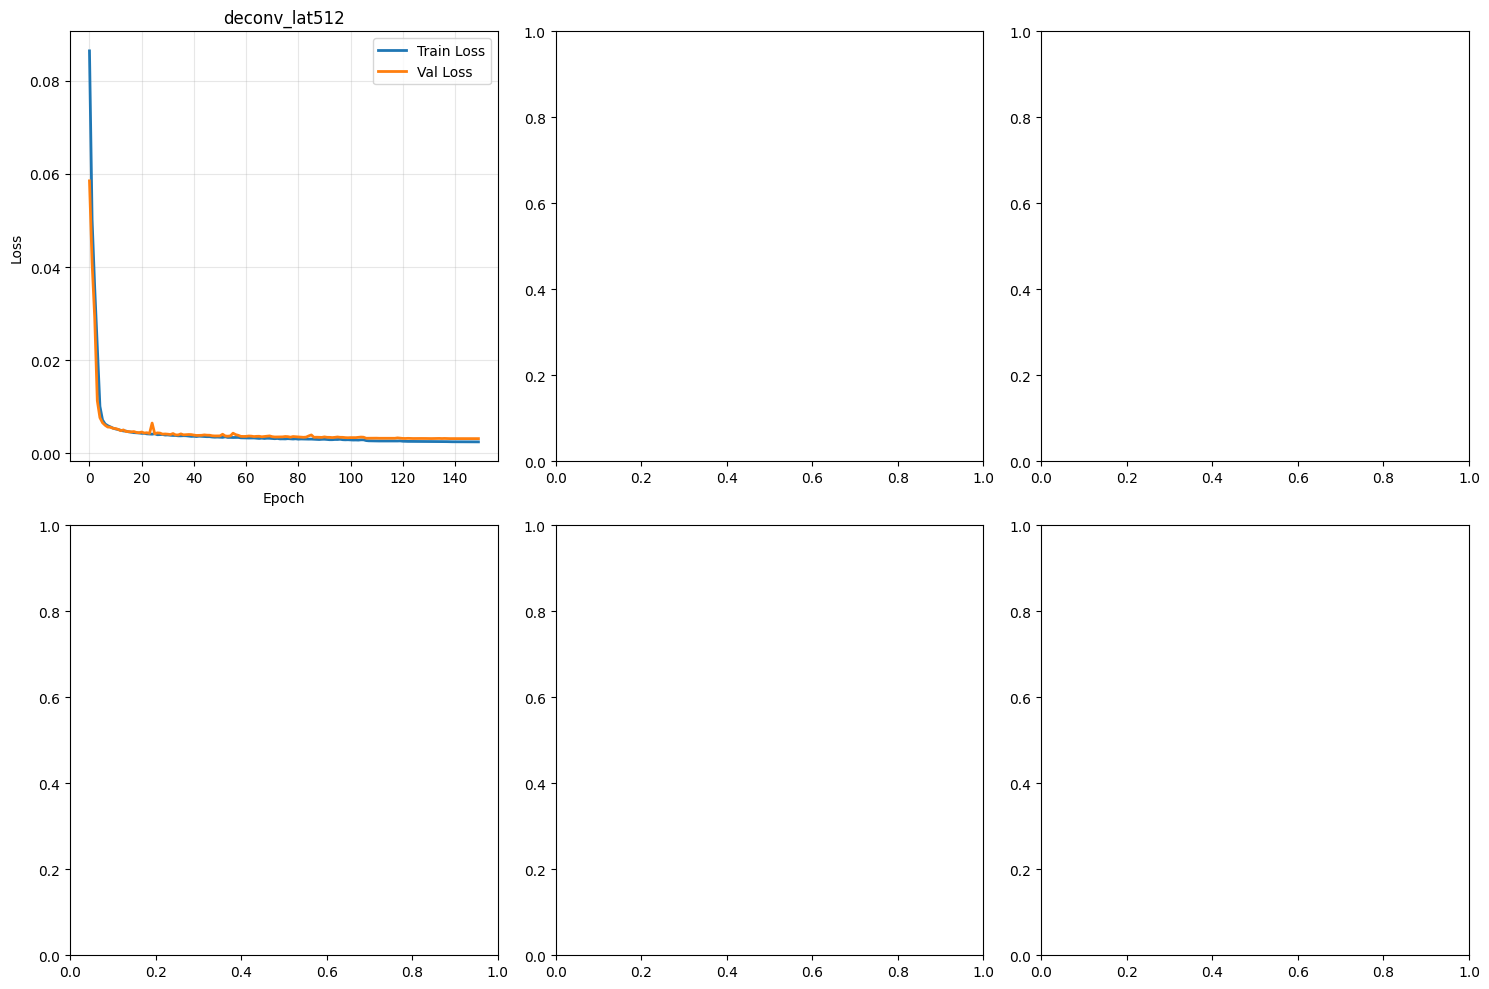

Training curves saved to output/Experiments/BottleneckDeconvTraining/training_curves.png


In [22]:
# Plot training curves for all models
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, (model_name, history) in enumerate(deconv_histories.items()):
    ax = axes[idx]
    ax.plot(history['train'], label='Train Loss', linewidth=2)
    ax.plot(history['val'], label='Val Loss', linewidth=2)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title(model_name)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "training_curves.png"), dpi=150)
plt.show()

print(f"Training curves saved to {os.path.join(output_dir, 'training_curves.png')}")

In [17]:
results_df = pd.read_csv('output/Experiments/BottleneckDeconvTraining/training_results.csv')

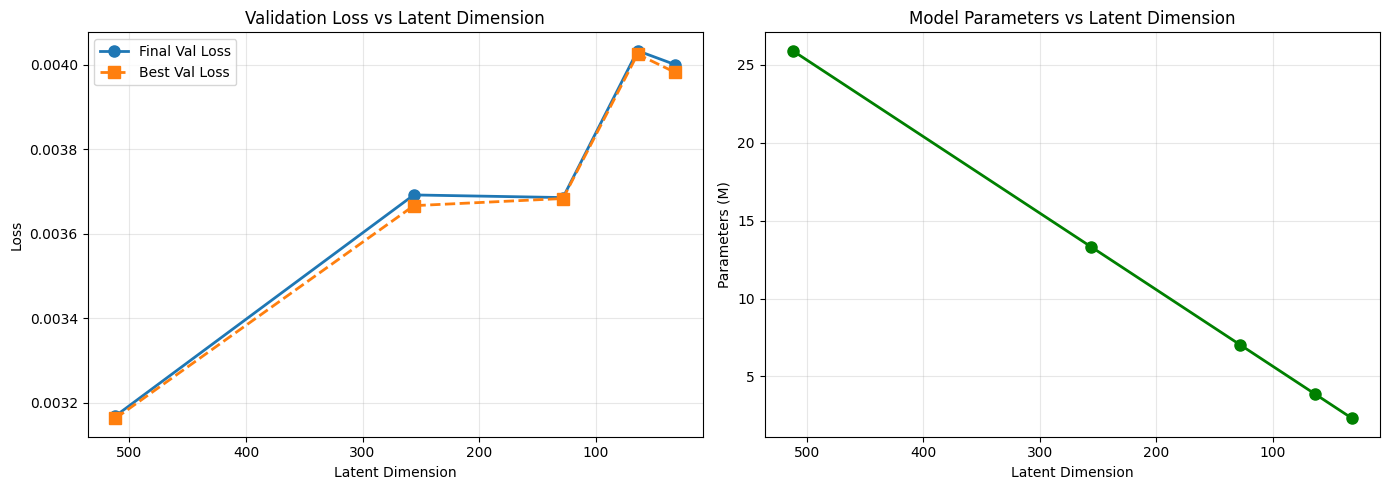

Comparison analysis saved to output/Experiments/BottleneckDeconvTraining/comparison_analysis.png


In [23]:
# Compare final losses
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Final validation loss vs latent dim
latent_dims = results_df['Latent Dim'].values
final_val_losses = results_df['Final Val Loss'].values
best_val_losses = results_df['Best Val Loss'].values

axes[0].plot(latent_dims, final_val_losses, 'o-', label='Final Val Loss', linewidth=2, markersize=8)
axes[0].plot(latent_dims, best_val_losses, 's--', label='Best Val Loss', linewidth=2, markersize=8)
axes[0].set_xlabel('Latent Dimension')
axes[0].set_ylabel('Loss')
axes[0].set_title('Validation Loss vs Latent Dimension')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].invert_xaxis()

# Parameters vs latent dim
params = results_df['Parameters'].values / 1e6
axes[1].plot(latent_dims, params, 'o-', color='green', linewidth=2, markersize=8)
axes[1].set_xlabel('Latent Dimension')
axes[1].set_ylabel('Parameters (M)')
axes[1].set_title('Model Parameters vs Latent Dimension')
axes[1].grid(True, alpha=0.3)
axes[1].invert_xaxis()

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "comparison_analysis.png"), dpi=150)
plt.show()

print(f"Comparison analysis saved to {os.path.join(output_dir, 'comparison_analysis.png')}")

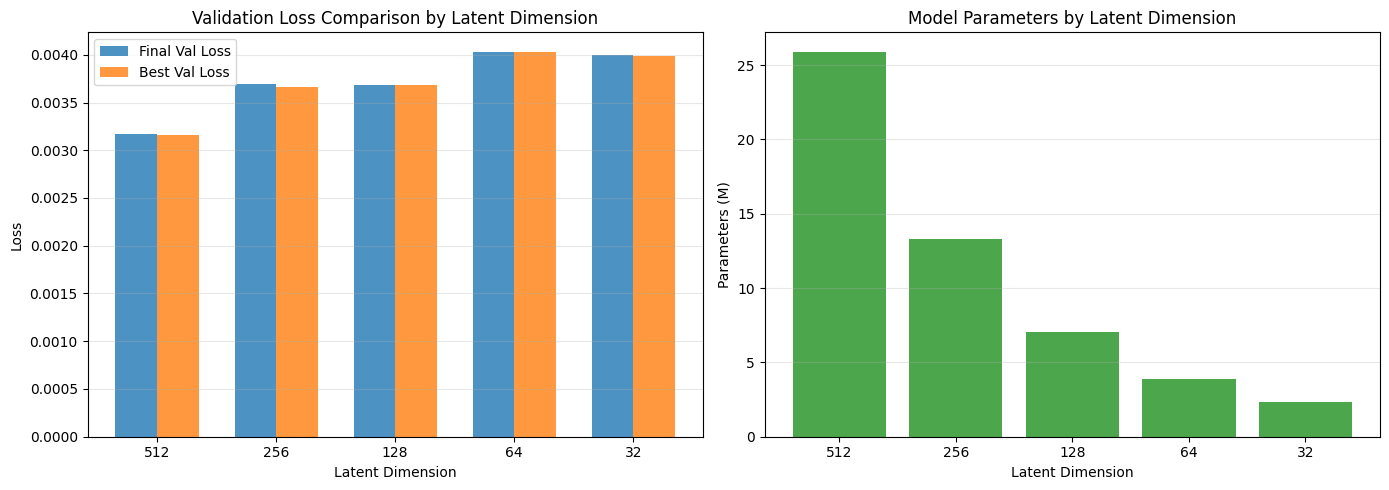

Bar chart saved to output/Experiments/BottleneckDeconvTraining/validation_loss_bars.png


In [24]:
# Bar chart for validation losses
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sort by latent dim for proper display
results_sorted = results_df.sort_values('Latent Dim', ascending=False)
latent_dims = results_sorted['Latent Dim'].values.astype(str)
final_val_losses = results_sorted['Final Val Loss'].values
best_val_losses = results_sorted['Best Val Loss'].values

x = np.arange(len(latent_dims))
width = 0.35

# Final vs Best validation loss
axes[0].bar(x - width/2, final_val_losses, width, label='Final Val Loss', alpha=0.8)
axes[0].bar(x + width/2, best_val_losses, width, label='Best Val Loss', alpha=0.8)
axes[0].set_xlabel('Latent Dimension')
axes[0].set_ylabel('Loss')
axes[0].set_title('Validation Loss Comparison by Latent Dimension')
axes[0].set_xticks(x)
axes[0].set_xticklabels(latent_dims)
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Parameters vs latent dim
params = results_sorted['Parameters'].values / 1e6
axes[1].bar(latent_dims, params, color='green', alpha=0.7)
axes[1].set_xlabel('Latent Dimension')
axes[1].set_ylabel('Parameters (M)')
axes[1].set_title('Model Parameters by Latent Dimension')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "validation_loss_bars.png"), dpi=150)
plt.show()

print(f"Bar chart saved to {os.path.join(output_dir, 'validation_loss_bars.png')}")

In [25]:
# Load all trained models from checkpoints
trained_models = {}
deconv_latent_dims = [512, 256, 128, 64, 32]

for latent_dim in deconv_latent_dims:
    model_name = f"deconv_lat{latent_dim}"
    checkpoint_path = os.path.join(output_dir, model_name, f"{model_name}_best.pth")
    
    if os.path.exists(checkpoint_path):
        print(f"Loading {model_name} from {checkpoint_path}...")
        model = build_model(latent_dim=latent_dim)
        model.load_state_dict(torch.load(checkpoint_path, map_location=device))
        trained_models[model_name] = model.eval()
        print(f"✓ Loaded {model_name}")
    else:
        print(f"✗ Checkpoint not found for {model_name}")

print(f"\nLoaded {len(trained_models)} models")

Loading deconv_lat512 from output/Experiments/BottleneckDeconvTraining/deconv_lat512/deconv_lat512_best.pth...
✓ Loaded deconv_lat512
Loading deconv_lat256 from output/Experiments/BottleneckDeconvTraining/deconv_lat256/deconv_lat256_best.pth...
✓ Loaded deconv_lat256
Loading deconv_lat128 from output/Experiments/BottleneckDeconvTraining/deconv_lat128/deconv_lat128_best.pth...
✓ Loaded deconv_lat128
Loading deconv_lat64 from output/Experiments/BottleneckDeconvTraining/deconv_lat64/deconv_lat64_best.pth...
✓ Loaded deconv_lat64
Loading deconv_lat32 from output/Experiments/BottleneckDeconvTraining/deconv_lat32/deconv_lat32_best.pth...
✓ Loaded deconv_lat32

Loaded 5 models


In [26]:
# Get a batch for reconstruction visualization
batch = next(iter(val_loader))
inp = batch['volume'].to(device)
labels = batch['label']

print(f"Input batch shape: {inp.shape}")
print(f"Labels: {labels}")

# Get reconstructions from all models
reconstructions = {}
with torch.no_grad():
    for model_name, model in trained_models.items():
        out = model(inp)
        reconstructions[model_name] = out

Input batch shape: torch.Size([4, 1, 64, 128, 128])
Labels: ['PD', 'PD', 'PD', 'Control']


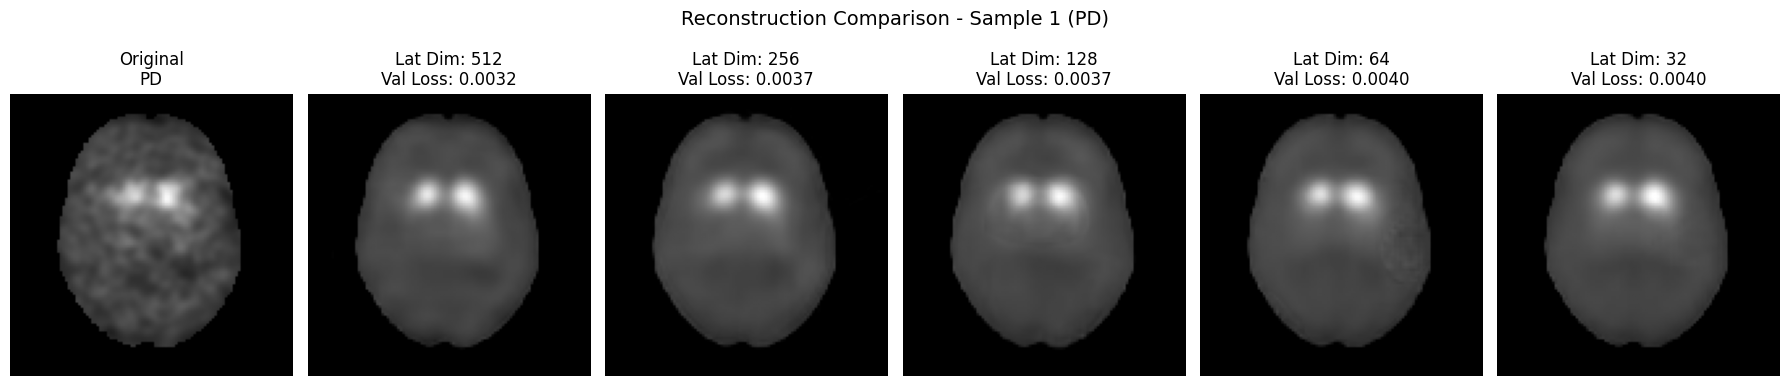

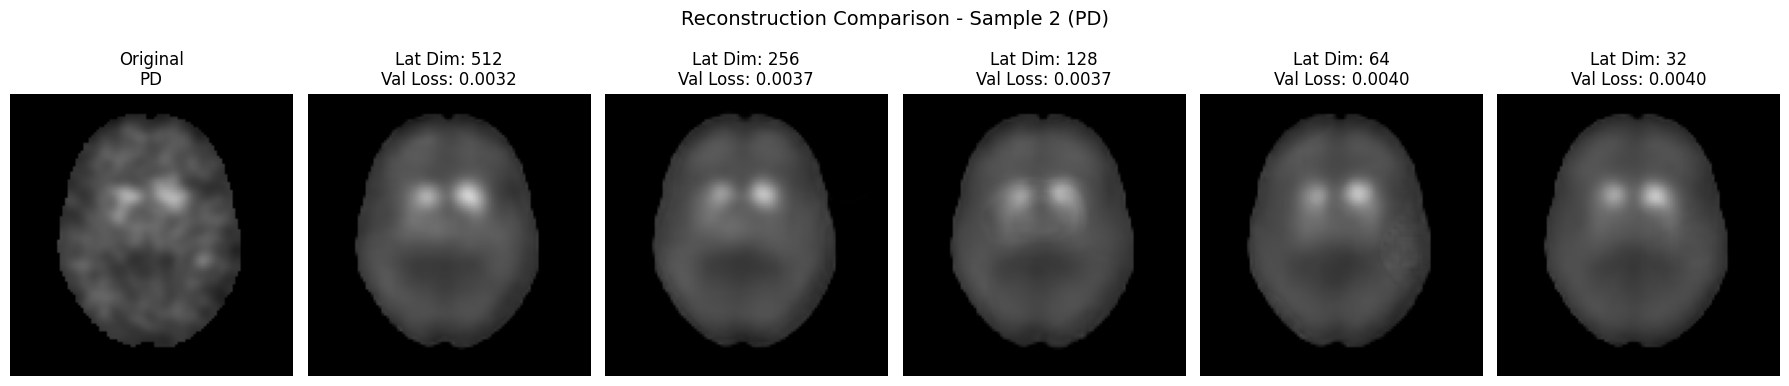

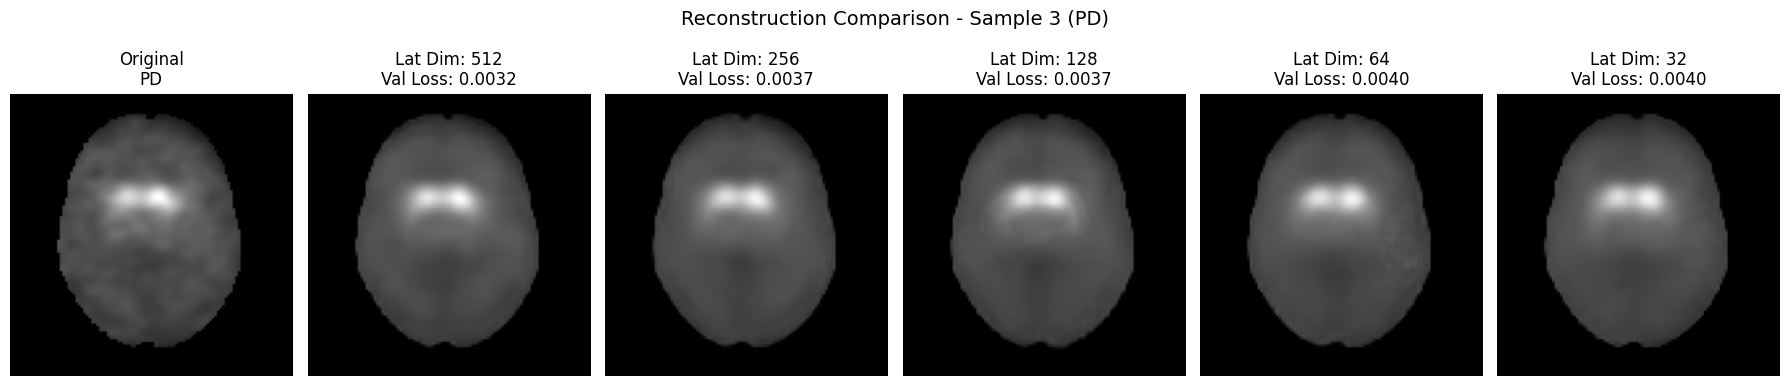

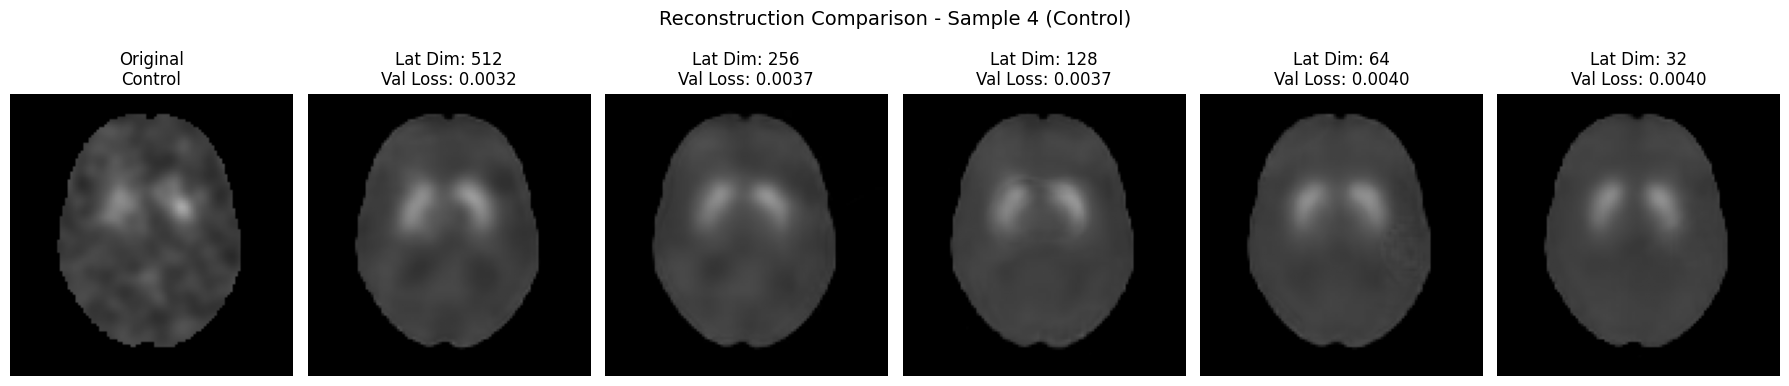

Reconstruction visualizations saved to output/Experiments/BottleneckDeconvTraining


In [27]:
# Visualize reconstructions for each sample in batch
for pIdx in range(min(4, inp.shape[0])):
    fig = plt.figure(figsize=(18, 4))
    
    # Original image
    ax = plt.subplot(1, len(deconv_latent_dims) + 1, 1)
    ax.imshow(inp[pIdx, 0, 32, 10:-10, 10:-10].cpu(), cmap='gray', vmin=-0., vmax=4.)
    ax.set_title(f"Original\n{labels[pIdx]}")
    ax.axis('off')
    
    # Reconstructions from each model
    for col_idx, (model_name, recon) in enumerate(reconstructions.items()):
        ax = plt.subplot(1, len(deconv_latent_dims) + 1, col_idx + 2)
        ax.imshow(recon[pIdx, 0, 32, 10:-10, 10:-10].cpu(), cmap='gray', vmin=-0., vmax=4.)
        # Extract latent dim from model name
        latent_dim = model_name.split('lat')[1]
        val_loss = results_df[results_df['Latent Dim'] == int(latent_dim)]['Final Val Loss'].values[0]
        ax.set_title(f"Lat Dim: {latent_dim}\nVal Loss: {val_loss:.4f}")
        ax.axis('off')
    
    plt.suptitle(f"Reconstruction Comparison - Sample {pIdx + 1} ({labels[pIdx]})", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, f"reconstruction_sample_{pIdx+1}.png"), dpi=150, bbox_inches='tight')
    plt.show()

print(f"Reconstruction visualizations saved to {output_dir}")

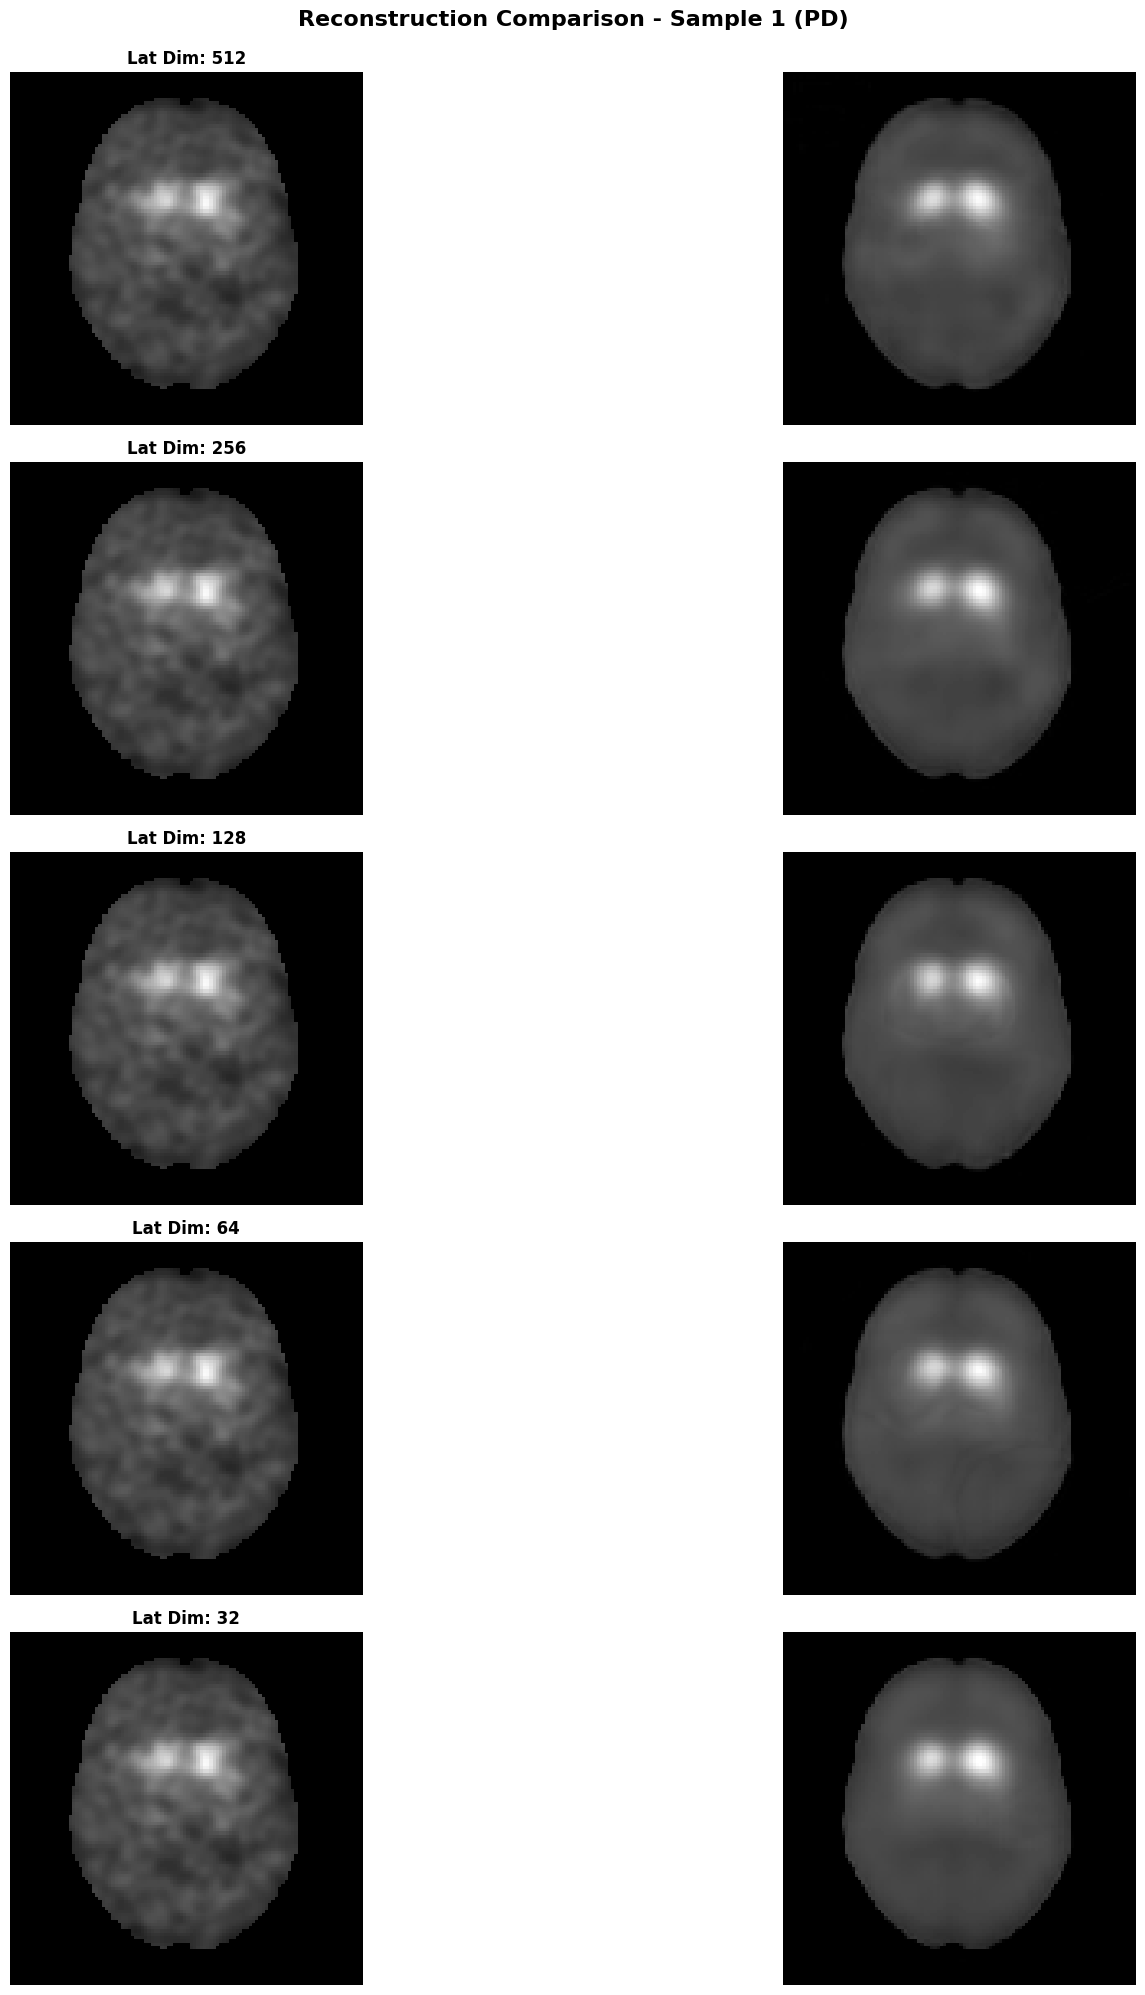

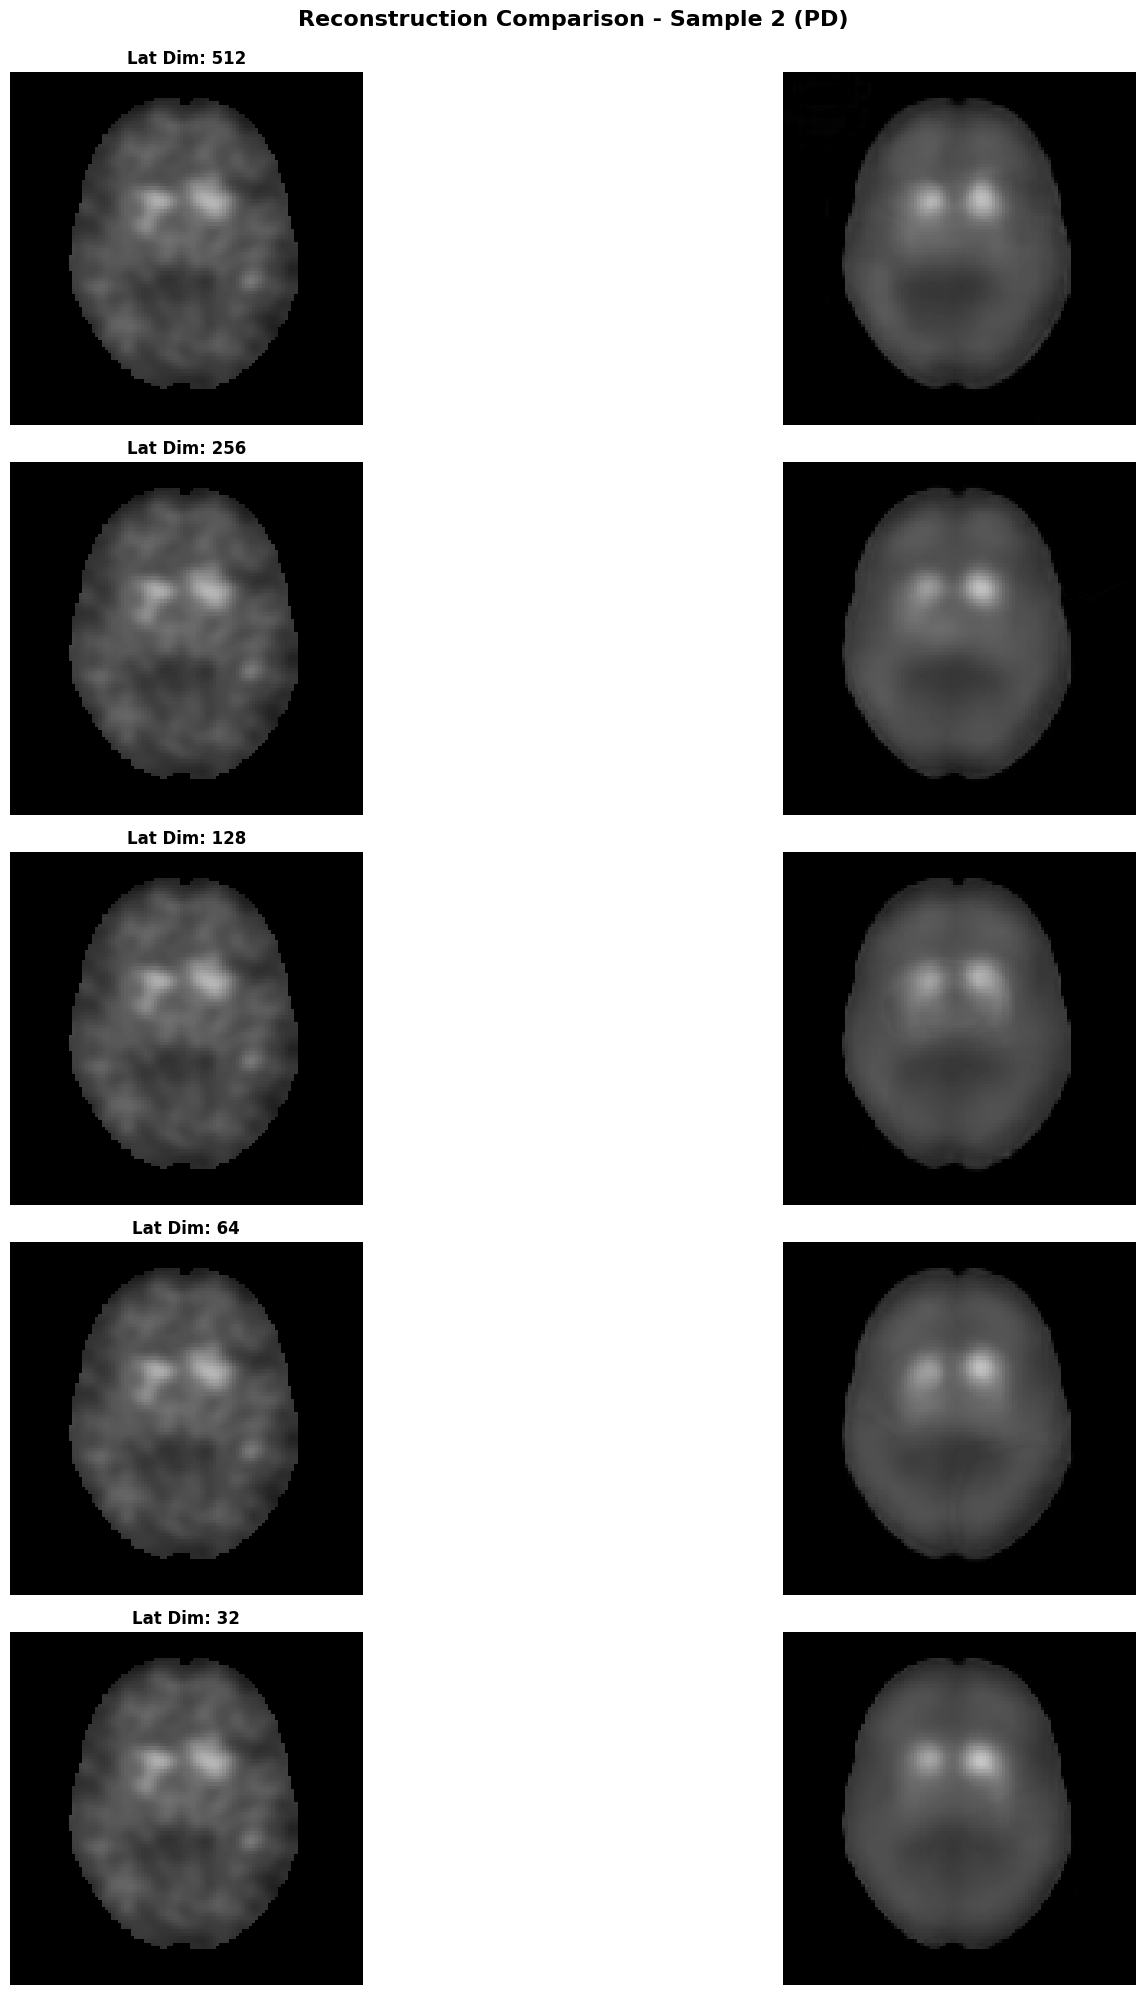

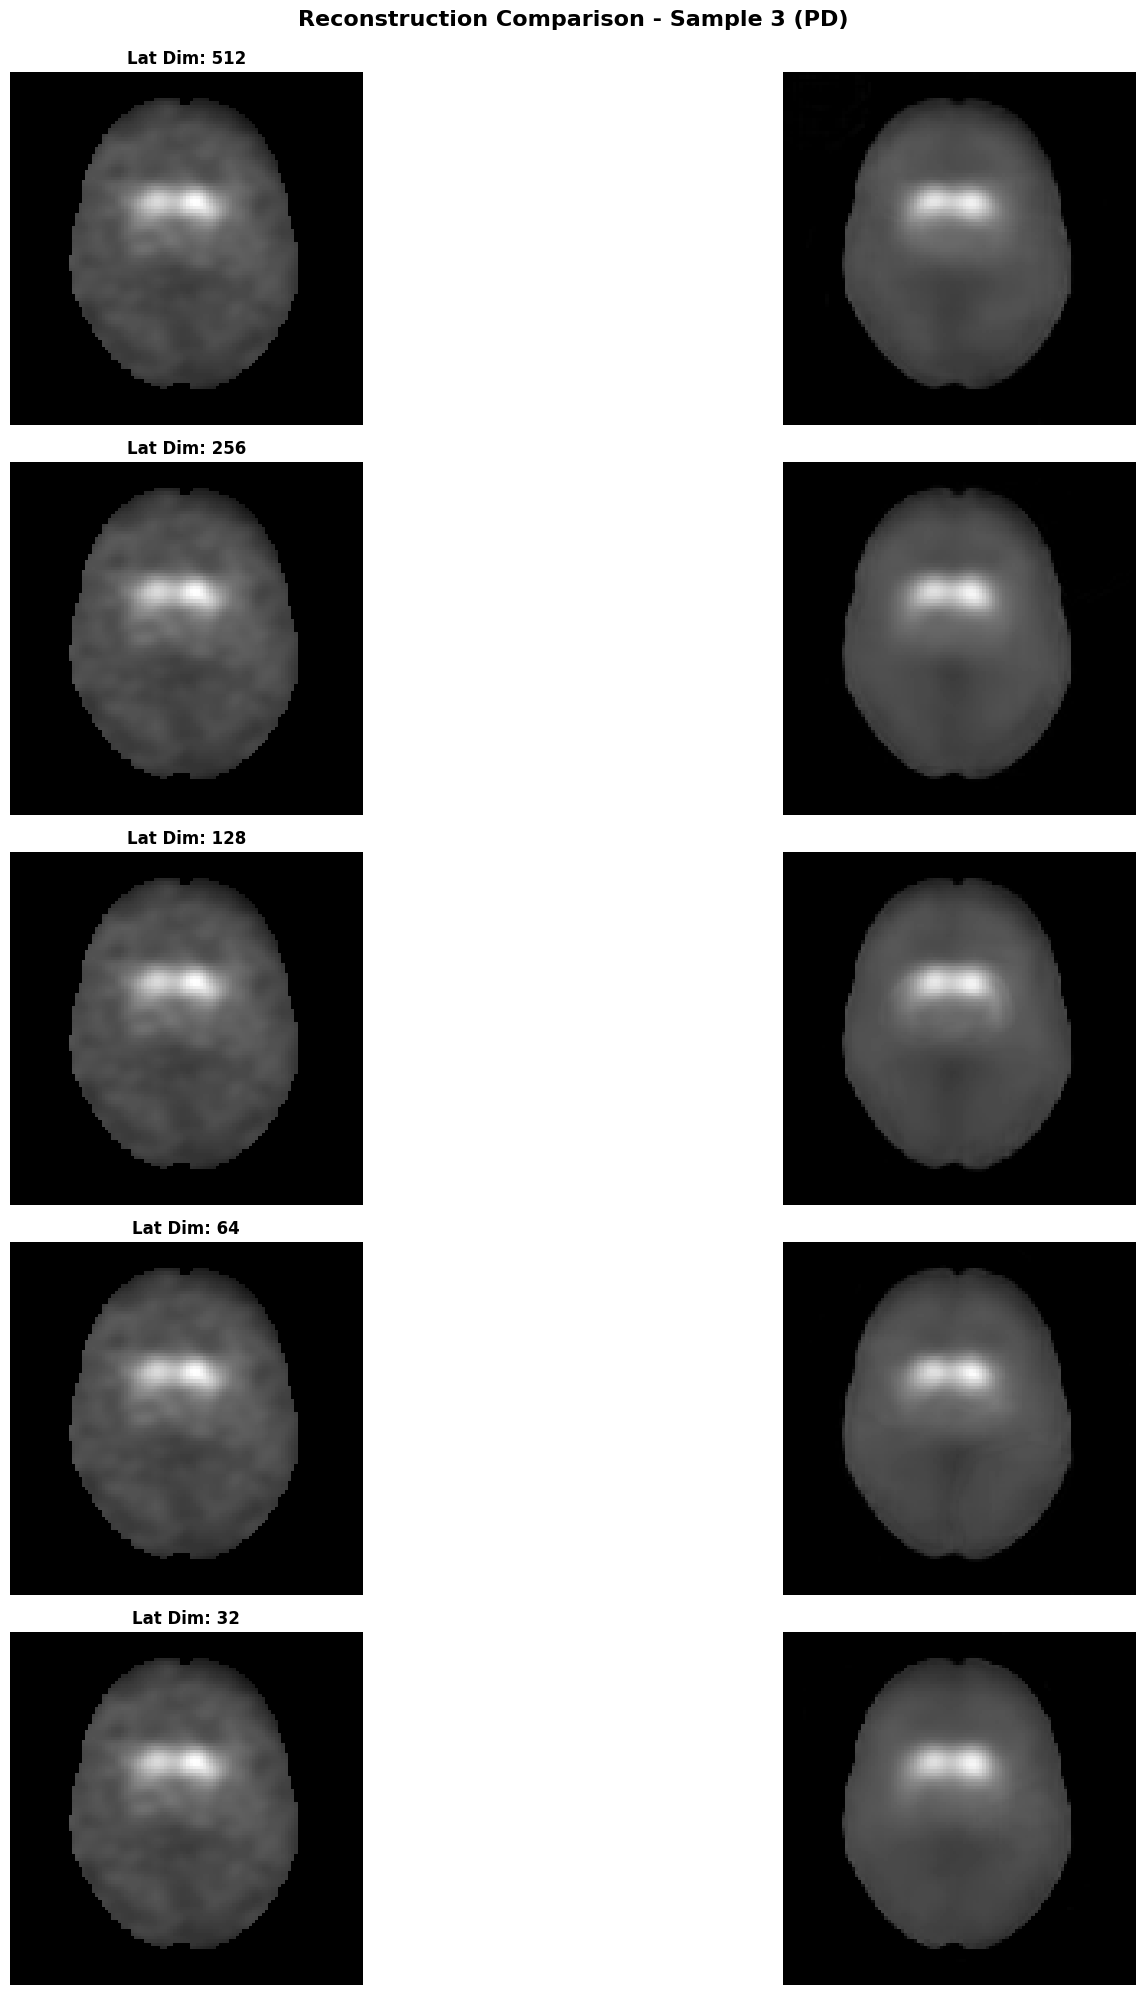

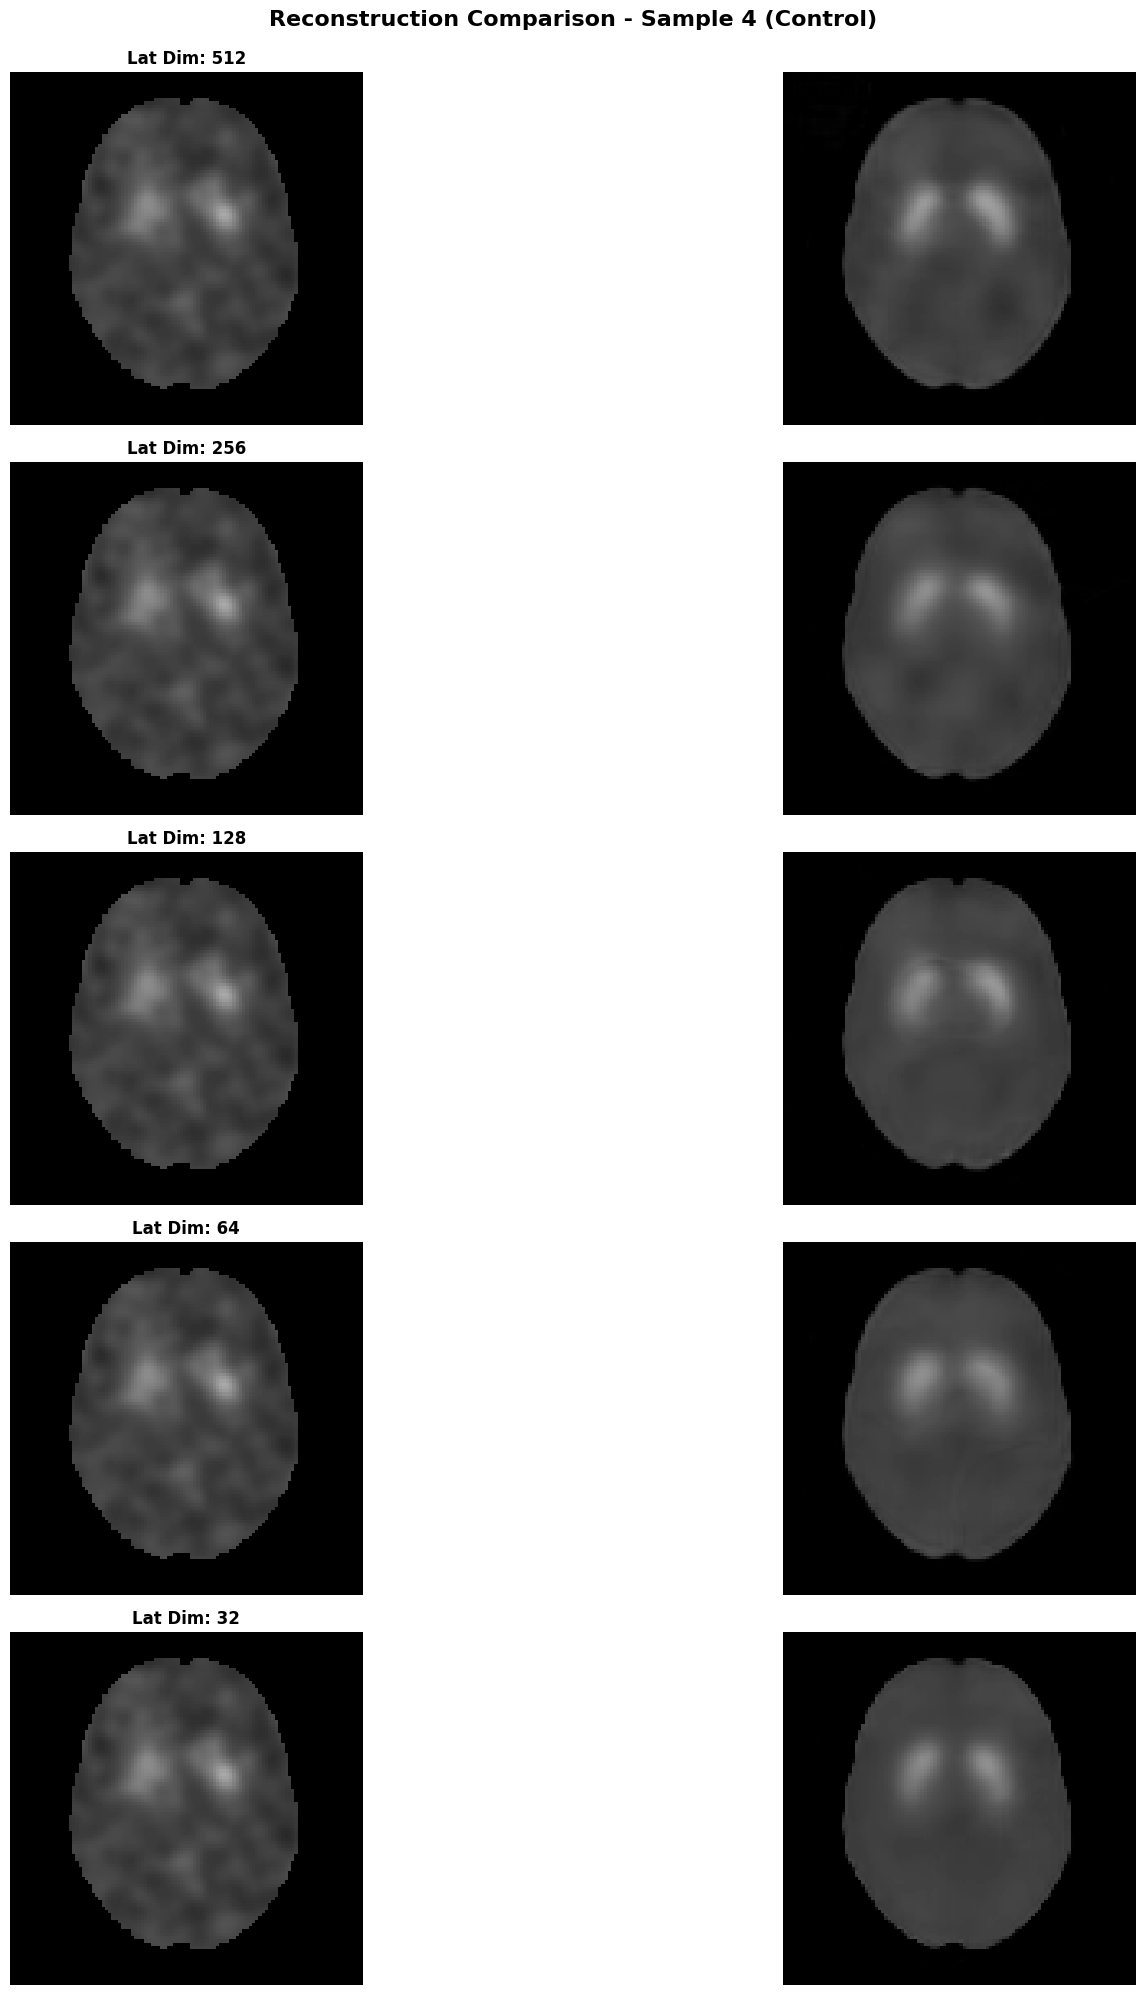

Reconstruction visualizations saved to output/Experiments/BottleneckDeconvTraining


In [13]:
# Visualize reconstructions for each sample in batch
for pIdx in range(min(4, inp.shape[0])):
    fig = plt.figure(figsize=(20, 20))
    
    # Loop through each latent dimension
    for col_idx, latent_dim in enumerate(deconv_latent_dims):
        model_name = f"deconv_lat{latent_dim}"
        recon = reconstructions[model_name]
        val_loss = results_df[results_df['Latent Dim'] == int(latent_dim)]['Final Val Loss'].values[0]
        
        # Original image
        ax = plt.subplot(len(deconv_latent_dims), 2, col_idx * 2 + 1)
        ax.imshow(inp[pIdx, 0, 32, 10:-10, 10:-10].cpu(), cmap='gray', vmin=-0., vmax=4.)
        if col_idx == 0:
            ax.set_ylabel(f"Sample {pIdx + 1}\n({labels[pIdx]})\nOriginal", fontsize=14, fontweight='bold')
        ax.set_title(f"Lat Dim: {latent_dim}", fontsize=12, fontweight='bold')
        ax.axis('off')
        
        # Reconstruction image
        ax = plt.subplot(len(deconv_latent_dims), 2, col_idx * 2 + 2)
        ax.imshow(recon[pIdx, 0, 32, 10:-10, 10:-10].cpu(), cmap='gray', vmin=-0., vmax=4.)
        ax.set_ylabel(f"Reconstruction\nLoss: {val_loss:.4f}", fontsize=14, fontweight='bold')
        ax.axis('off')
    
    plt.suptitle(f"Reconstruction Comparison - Sample {pIdx + 1} ({labels[pIdx]})", fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, f"reconstruction_sample_{pIdx+1}.png"), dpi=150, bbox_inches='tight')
    plt.show()

print(f"Reconstruction visualizations saved to {output_dir}")

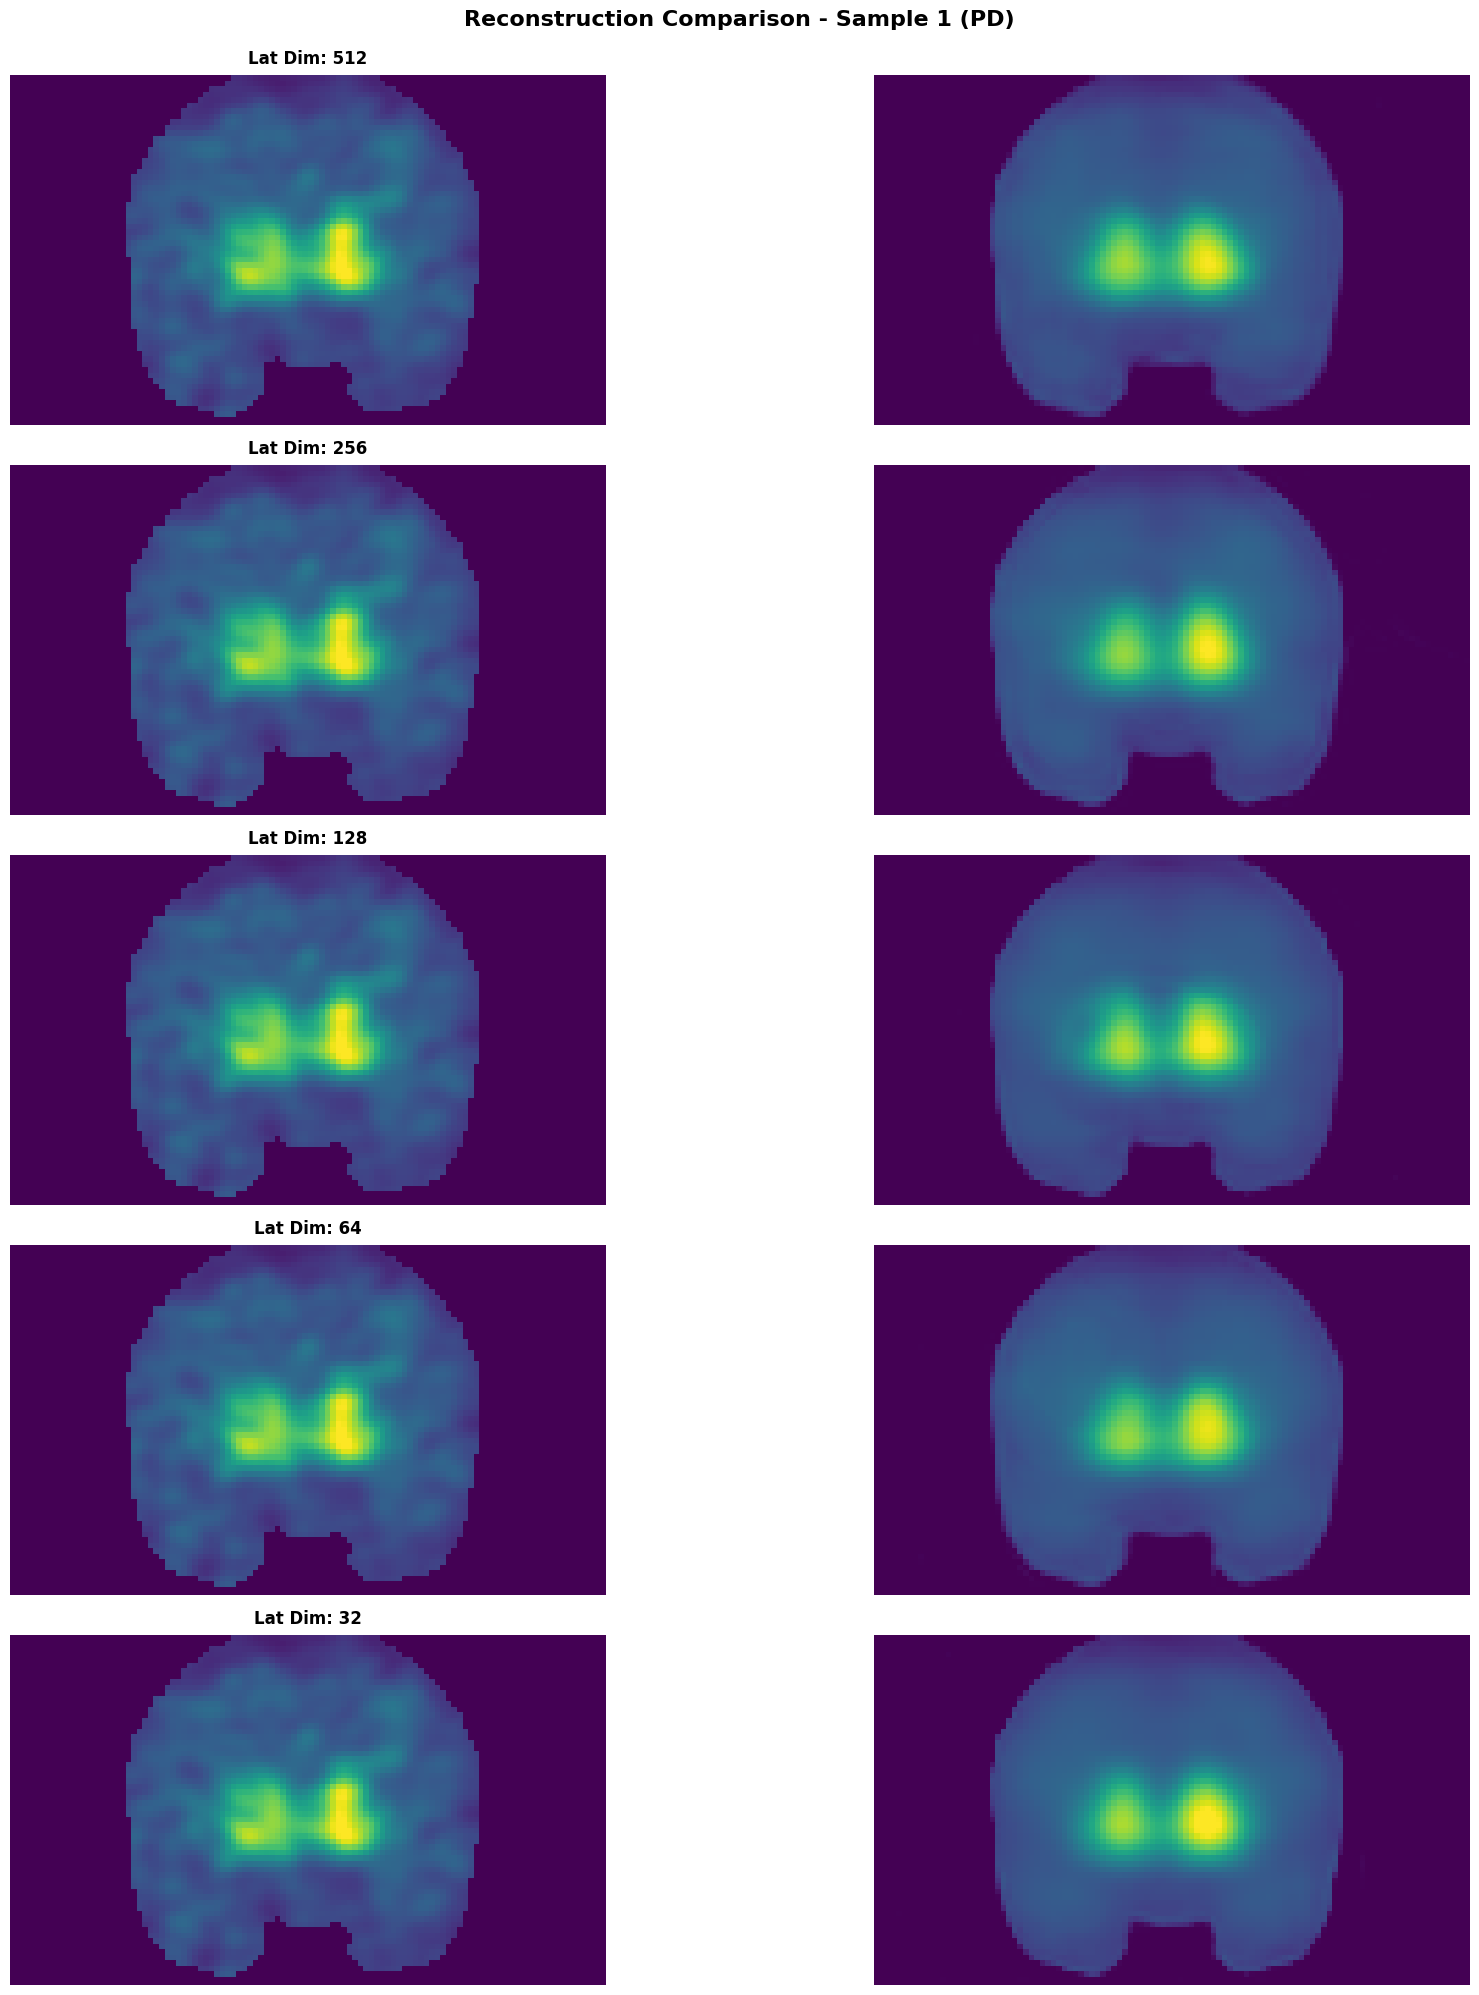

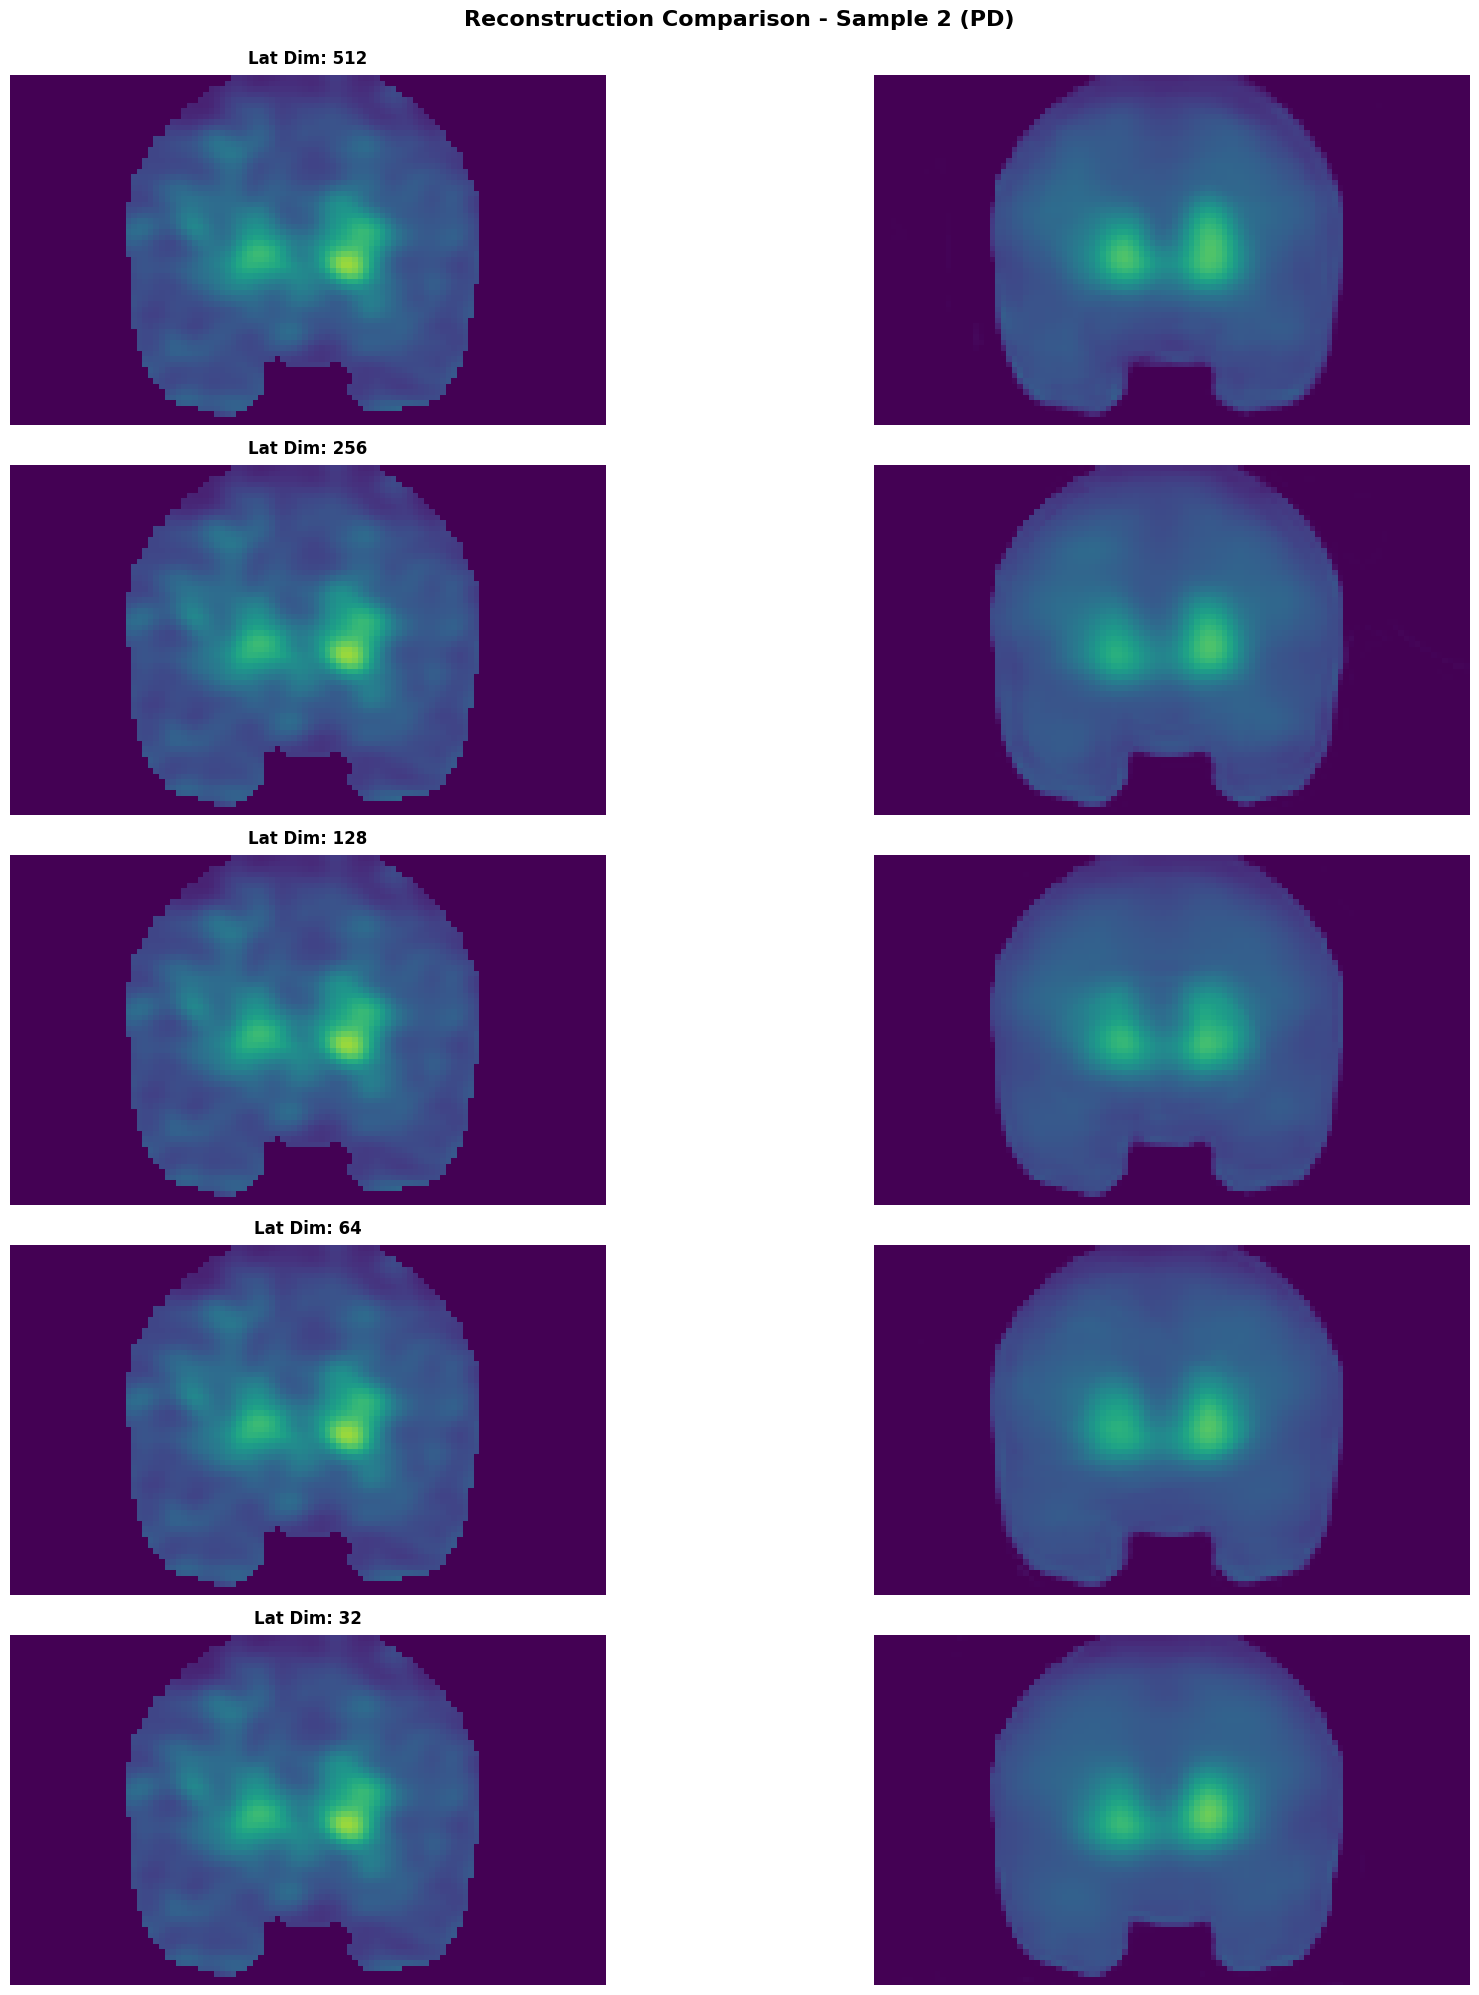

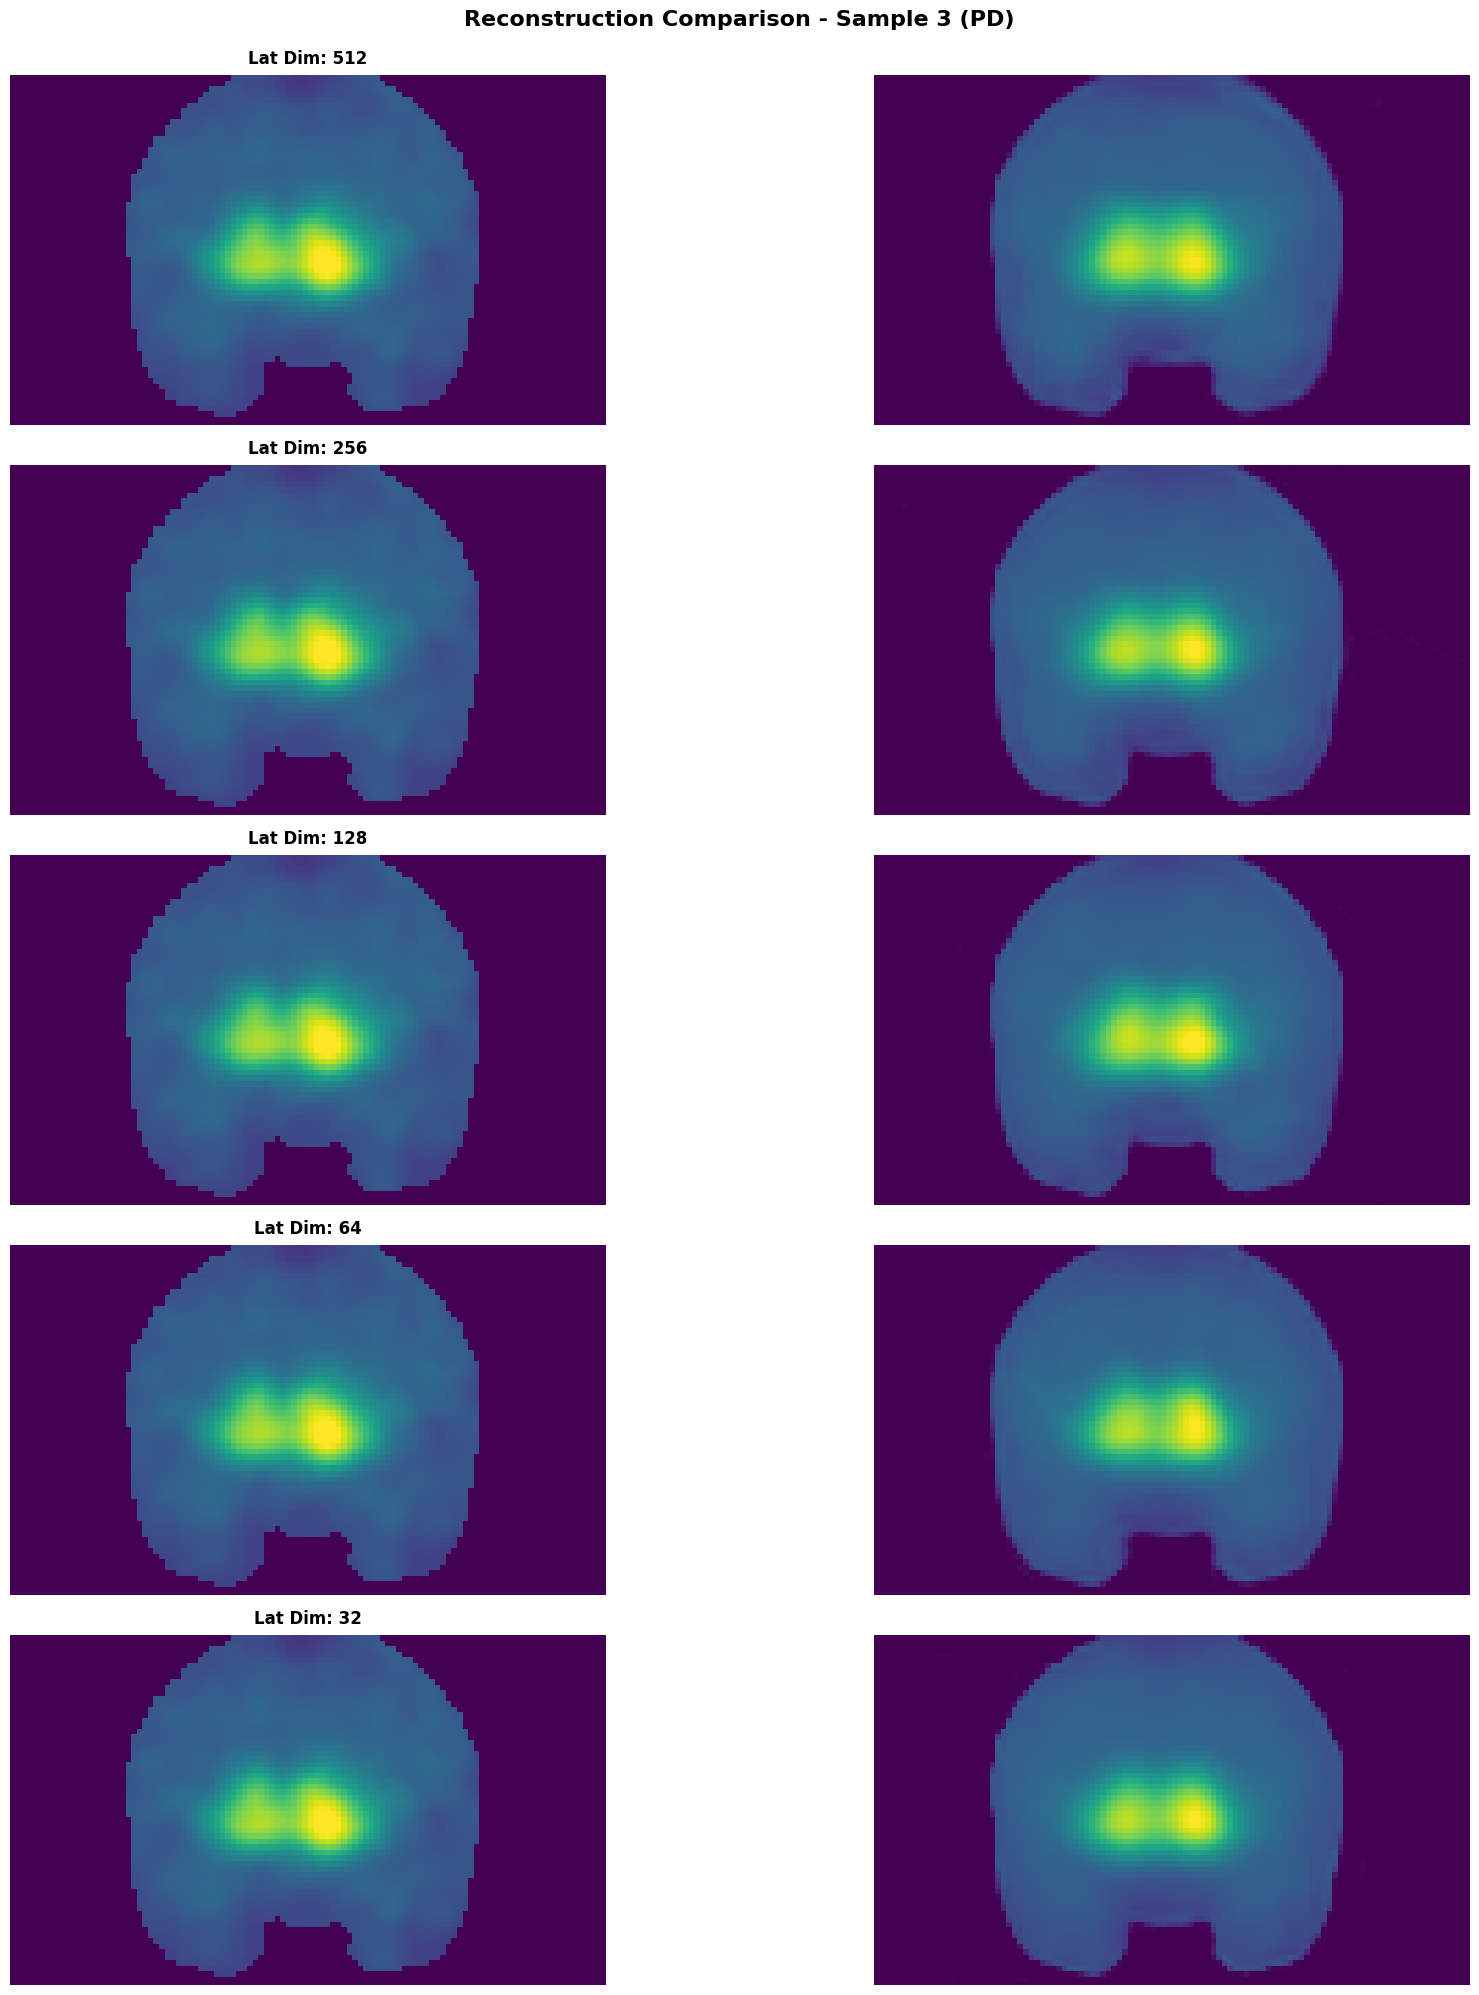

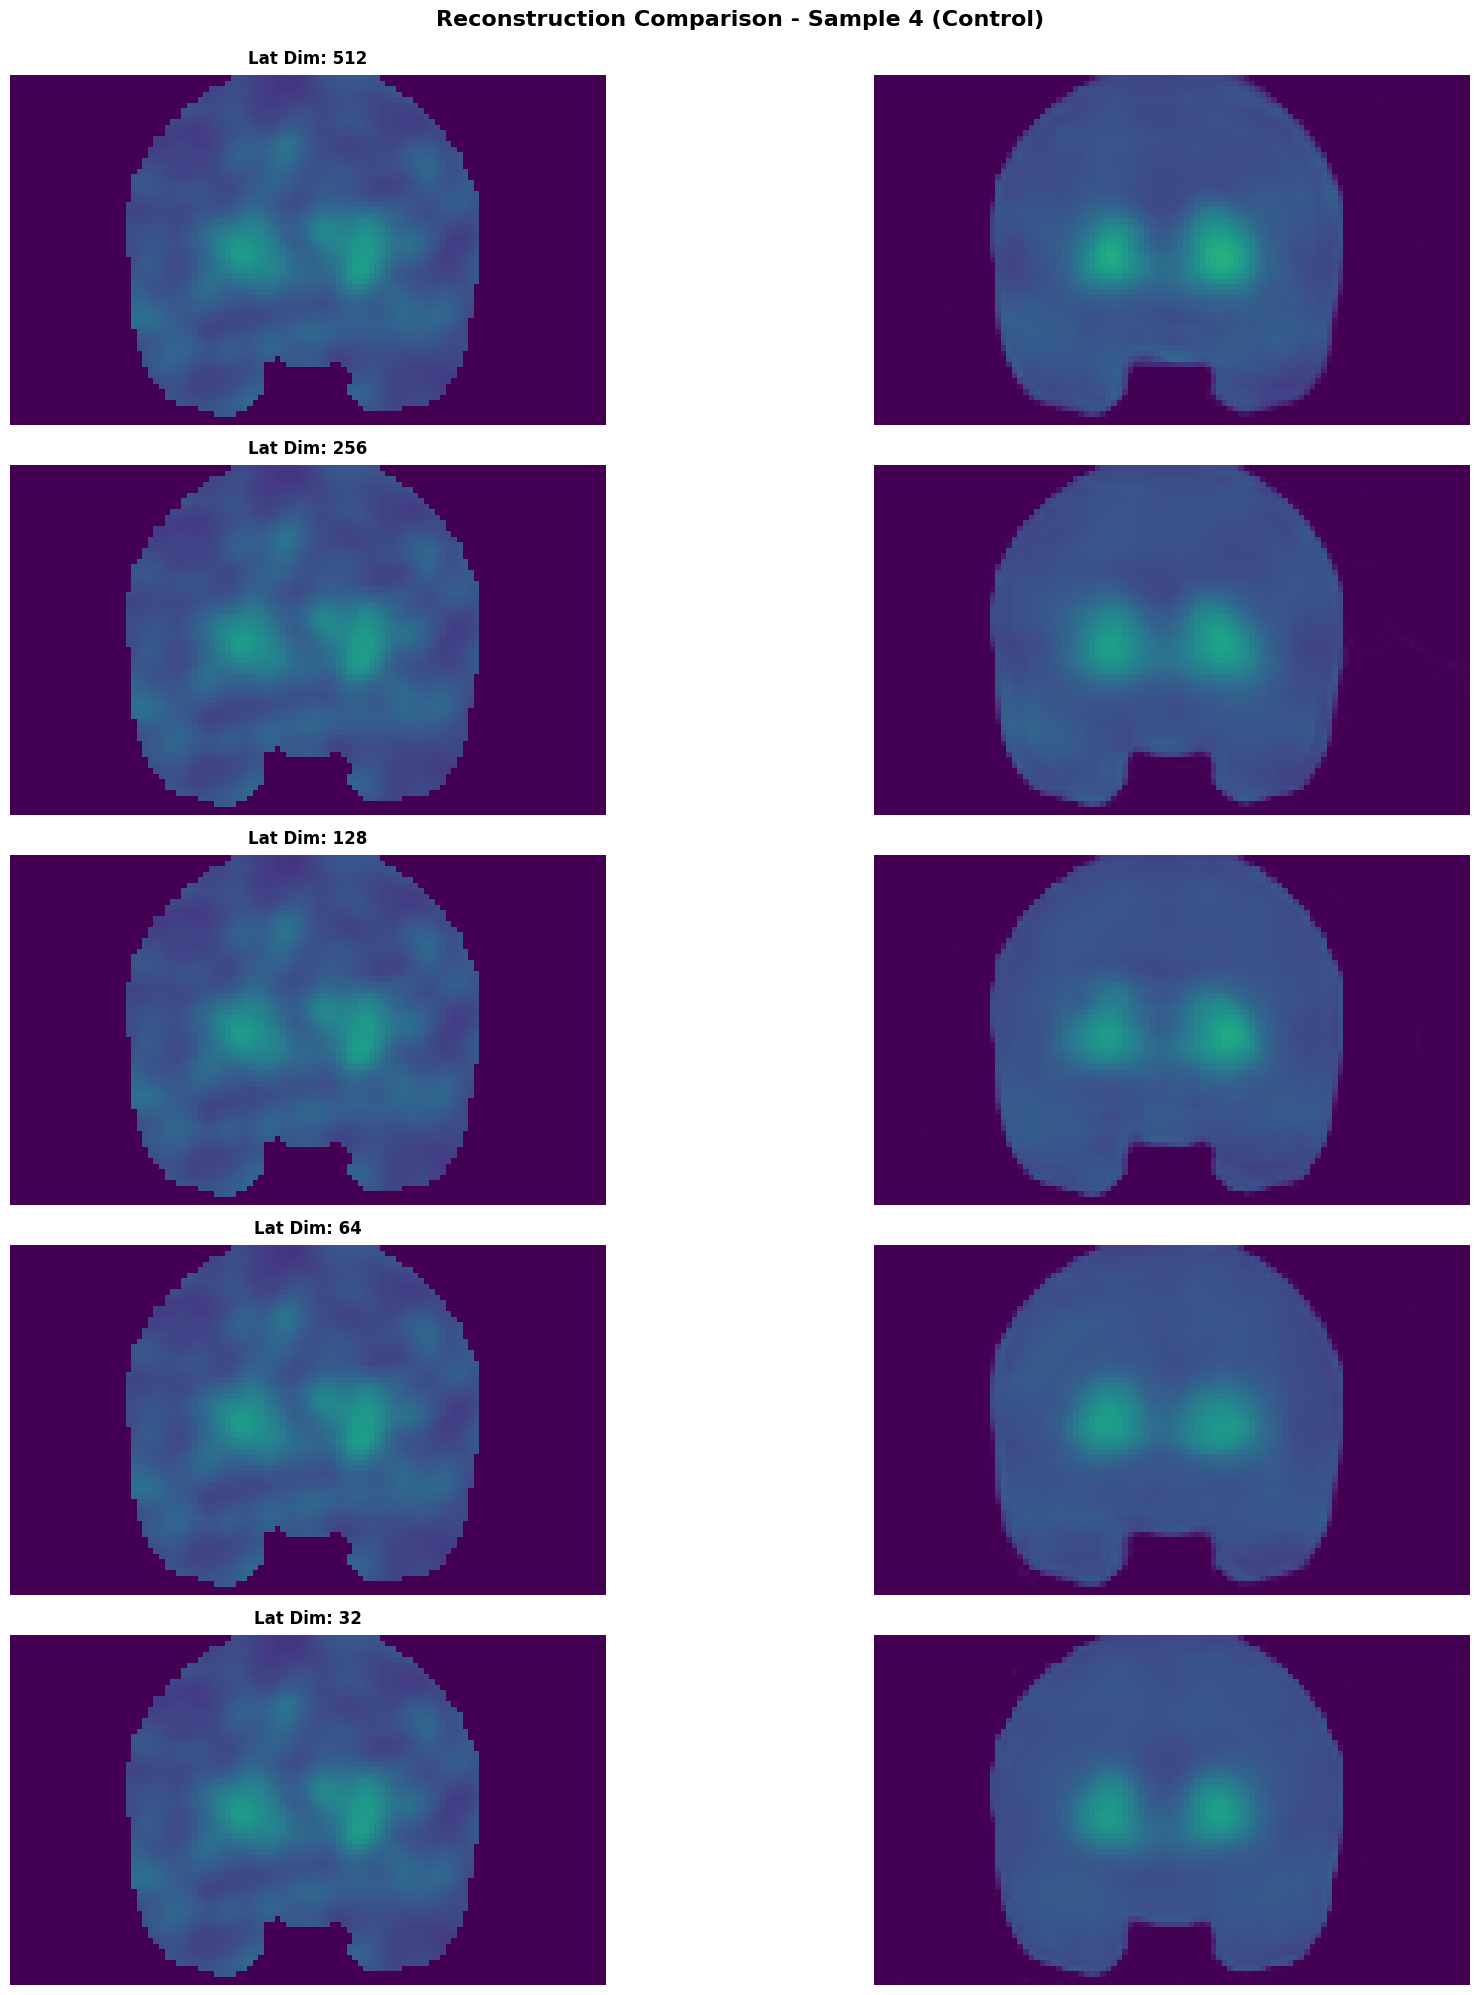

Reconstruction visualizations saved to output/Experiments/BottleneckDeconvTraining


In [14]:
# Visualize reconstructions for each sample in batch
for pIdx in range(min(4, inp.shape[0])):
    fig = plt.figure(figsize=(20, 20))
    
    # Loop through each latent dimension
    for col_idx, latent_dim in enumerate(deconv_latent_dims):
        model_name = f"deconv_lat{latent_dim}"
        recon = reconstructions[model_name]
        val_loss = results_df[results_df['Latent Dim'] == int(latent_dim)]['Final Val Loss'].values[0]
        
        # Original image
        ax = plt.subplot(len(deconv_latent_dims), 2, col_idx * 2 + 1)
        ax.imshow(inp[pIdx, 0, :, 50, 10:-10].cpu(), cmap='viridis', vmin=-0., vmax=4.)
        ax.set_ylim(0, 64)
        if col_idx == 0:
            ax.set_ylabel(f"Sample {pIdx + 1}\n({labels[pIdx]})\nOriginal", fontsize=14, fontweight='bold')
        ax.set_title(f"Lat Dim: {latent_dim}", fontsize=12, fontweight='bold')
        ax.axis('off')
        
        # Reconstruction image
        ax = plt.subplot(len(deconv_latent_dims), 2, col_idx * 2 + 2)
        ax.imshow(recon[pIdx, 0, :, 50, 10:-10].cpu(), cmap='viridis', vmin=-0., vmax=4.)
        ax.set_ylim(0, 64)
        ax.set_ylabel(f"Reconstruction\nLoss: {val_loss:.4f}", fontsize=14, fontweight='bold')
        ax.axis('off')
    
    plt.suptitle(f"Reconstruction Comparison - Sample {pIdx + 1} ({labels[pIdx]})", fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, f"reconstruction_sample_{pIdx+1}.png"), dpi=150, bbox_inches='tight')
    plt.show()

print(f"Reconstruction visualizations saved to {output_dir}")